In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

In [11]:
# Total number of data points: 18.752.333
# Number of slices: 143.680
# ~ 130 data points per slice [6, 499]

#       Date	                    Texp	        size
# count	143680	                    143680.000000	143680.000000
# mean	2016-10-28  16:46:33.407572	0.540287	    130.514567
# min	2000-01-03  00:00:00	    0.002738	    6.000000
# 25%	2012-12-19  00:00:00	    0.071184	    62.000000
# 50%	2018-03-27  00:00:00	    0.238193	    115.000000
# 75%	2022-02-28  00:00:00	    0.750171	    170.000000
# max	2024-12-31  00:00:00	    6.048000	    499.000000
# std	NaN	                        0.755189	    89.166256

df = pd.read_parquet("data/ivdata.parquet")
df.head()

,Date,Expiry,Texp,z,w
219043,2000-01-03,2000-01-22,0.052019,-0.400915,NaN
219044,2000-01-03,2000-01-22,0.052019,-0.350905,0.000097
219045,2000-01-03,2000-01-22,0.052019,-0.326807,0.000086
219046,2000-01-03,2000-01-22,0.052019,-0.303277,0.000076
219047,2000-01-03,2000-01-22,0.052019,-0.280287,0.000066


In [12]:
# Group data into maturity bins.
bins = np.array([
    -np.inf, 
    7,
    30, 
    90,
    180, 
    365, 
    np.inf])

labels= [
    "<=1wk",    # 0-7 days
    "1m",       # 7-30 days
    "3m",       # 30-90 days
    "6m",       # 90 - 180 days
    "1y",       # 180 - 365 days
    ">1y"       # 365+ days
]

# Calculate days to expiry
df["DTE"] =  (df["Expiry"] - df["Date"]).dt.days

df["Maturity-Group"] = pd.cut(
    df["DTE"],
    bins=list(bins),
    labels=labels,
    include_lowest=True
)
df.head()

,Date,Expiry,Texp,z,w,DTE,Maturity-Group
219043,2000-01-03,2000-01-22,0.052019,-0.400915,NaN,19,1m
219044,2000-01-03,2000-01-22,0.052019,-0.350905,0.000097,19,1m
219045,2000-01-03,2000-01-22,0.052019,-0.326807,0.000086,19,1m
219046,2000-01-03,2000-01-22,0.052019,-0.303277,0.000076,19,1m
219047,2000-01-03,2000-01-22,0.052019,-0.280287,0.000066,19,1m


In [13]:
def format_bytes(n_bytes):
    units = ["B", "KB", "MB", "GB", "TB", "PB"]

    size = float(n_bytes)

    for unit in units:
        if size < 1024 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024

In [32]:
import pickle

from scipy.interpolate import interp1d
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

min_points_per_slice = 20
num_grid_points = 20
num_clusters_per_group = 9

zgrid = np.linspace(-1, 1, num_grid_points)
results_list = []

data_matrix = None
cluster_array = None

R = {}

for mLabel, maturityDf in  df.groupby("Maturity-Group"):
    feature_vectors = []
    group_keys = []

    skipped_slices = 0

    for (date, texp), group in tqdm(maturityDf.groupby(["Date","Texp"]), desc=f"Maturity {mLabel}:"):
        # Remove NaN values
        group = group.dropna(subset=["z", "w"])
        mask = group["z"] < 0
        
        # Ignore slice if it has to few data points
        if len(group) < min_points_per_slice:
            continue
        
        # Normalise values into [-1, 1]
        z_min = abs(group.loc[mask, "z"].min())
        z_max = group.loc[~mask, "z"].max()
        
        # Skip slices that cannot be normalized
        if not (z_min > 0 and z_max > 0):
            # print("Skipping", date, texp)
            skipped_slices += 1
            continue
        
        z_norm = group["z"] / z_min
        z_norm[~mask] = group.loc[~mask, "z"] / z_max
        
        # Interpolate to common grid
        w_fixed = np.interp(zgrid, z_norm, group["w"])
        
        feature_vectors.append(w_fixed)
        group_keys.append((date, texp))
        
    X = np.array(feature_vectors)

    print("Skipped Slices", skipped_slices)
    print(f"Feature Matrix size: {X.shape}, {format_bytes(X.nbytes)} bytes")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
     
    mbk = MiniBatchKMeans(
        n_clusters=num_clusters_per_group, 
        batch_size=10_024, 
        random_state=42, 
        n_init="auto"
    )
    cluster_labels = mbk.fit_predict(X_scaled)
    results = pd.DataFrame(group_keys, columns=['Date', 'Texp'])
    results['Cluster'] = cluster_labels
    
    results_list.append(results)
    
    R[mLabel] = {
        "labels": cluster_labels,
        "data": X,
        "keys": group_keys
    }

with open("data/cluster/res.pkl", "wb") as f:
    pickle.dump(R, f)

Maturity <=1wk:: 100%|██████████| 10299/10299 [00:26<00:00, 395.94it/s]


Skipped Slices 0
Feature Matrix size: (9502, 20), 1.45 MB bytes


Maturity 1m:: 100%|██████████| 31400/31400 [01:27<00:00, 360.14it/s]


Skipped Slices 0
Feature Matrix size: (31226, 20), 4.76 MB bytes


Maturity 3m:: 100%|██████████| 30989/30989 [01:23<00:00, 370.89it/s]


...

Skipped Slices 0
Feature Matrix size: (20687, 20), 3.16 MB bytes


Maturity 1y:: 100%|██████████| 27025/27025 [01:02<00:00, 434.03it/s]


Skipped Slices 22
Feature Matrix size: (25962, 20), 3.96 MB bytes


Maturity >1y:: 100%|██████████| 22597/22597 [00:47<00:00, 479.49it/s]


Skipped Slices 462
Feature Matrix size: (21039, 20), 3.21 MB bytes


In [ ]:
# data_matrix = np.load("data/cluster/data.npy")
# cluster_array = np.load("data/cluster/labels.npy", allow_pickle=True)
# labels = cluster_array[:, 2]

In [39]:
def plot_cluster_profiles(X, labels, title, filename, x=None, show_individual=False):
    """
    Plot cluster means and variation bands.

    Parameters
    ----------
    X : ndarray of shape (M, N)
        Matrix of M profiles with N points each.

    labels : ndarray of shape (M,)
        Cluster labels for each profile.

    x : ndarray of shape (N,), optional
        X-axis values. If None, uses 0, ..., N-1.

    show_individual : bool, default=False
        Whether to plot all individual profiles in the background.
    """

    if x is None:
        x = np.arange(X.shape[1])

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        # sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, cluster in zip(axes, clusters):

        cluster_data = X[labels == cluster]

        if len(cluster_data) == 0:
            ax.set_title(f"Cluster {cluster} (empty)")
            continue

        mean = cluster_data.mean(axis=0)
        std = cluster_data.std(axis=0)

        if show_individual:
            for curve in cluster_data:
                ax.plot(x, curve, alpha=0.1)

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.3,
            label="±1 std"
        )

        ax.plot(
            x,
            mean,
            linewidth=2,
            label="Mean"
        )

        ax.set_title(
            f"Cluster {cluster}\nN={len(cluster_data)}"
        )

        ax.grid(alpha=0.3)

        if cluster == clusters[0]:
            ax.legend()

    # Remove unused axes
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Profile coordinate")
    fig.supylabel("Value")

    fig.suptitle(f'Cluster Group: {title}')

    plt.tight_layout()
    plt.savefig(f"images/clusters/{filename}")
    plt.show()

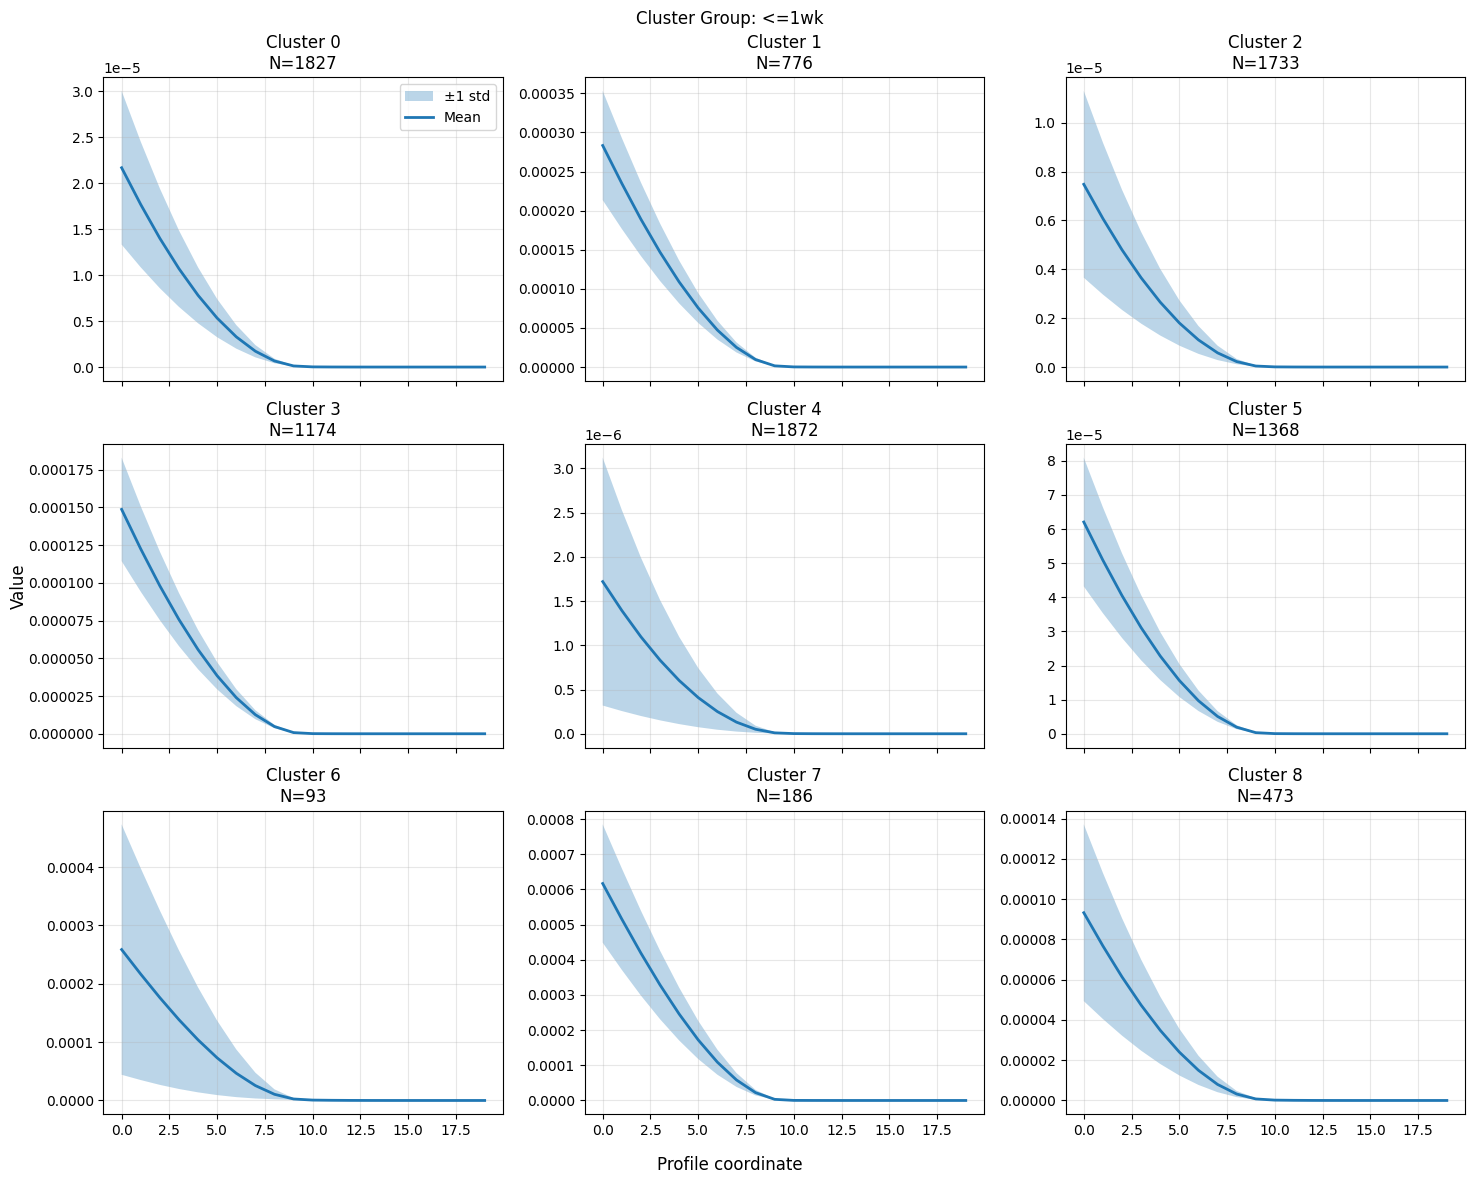

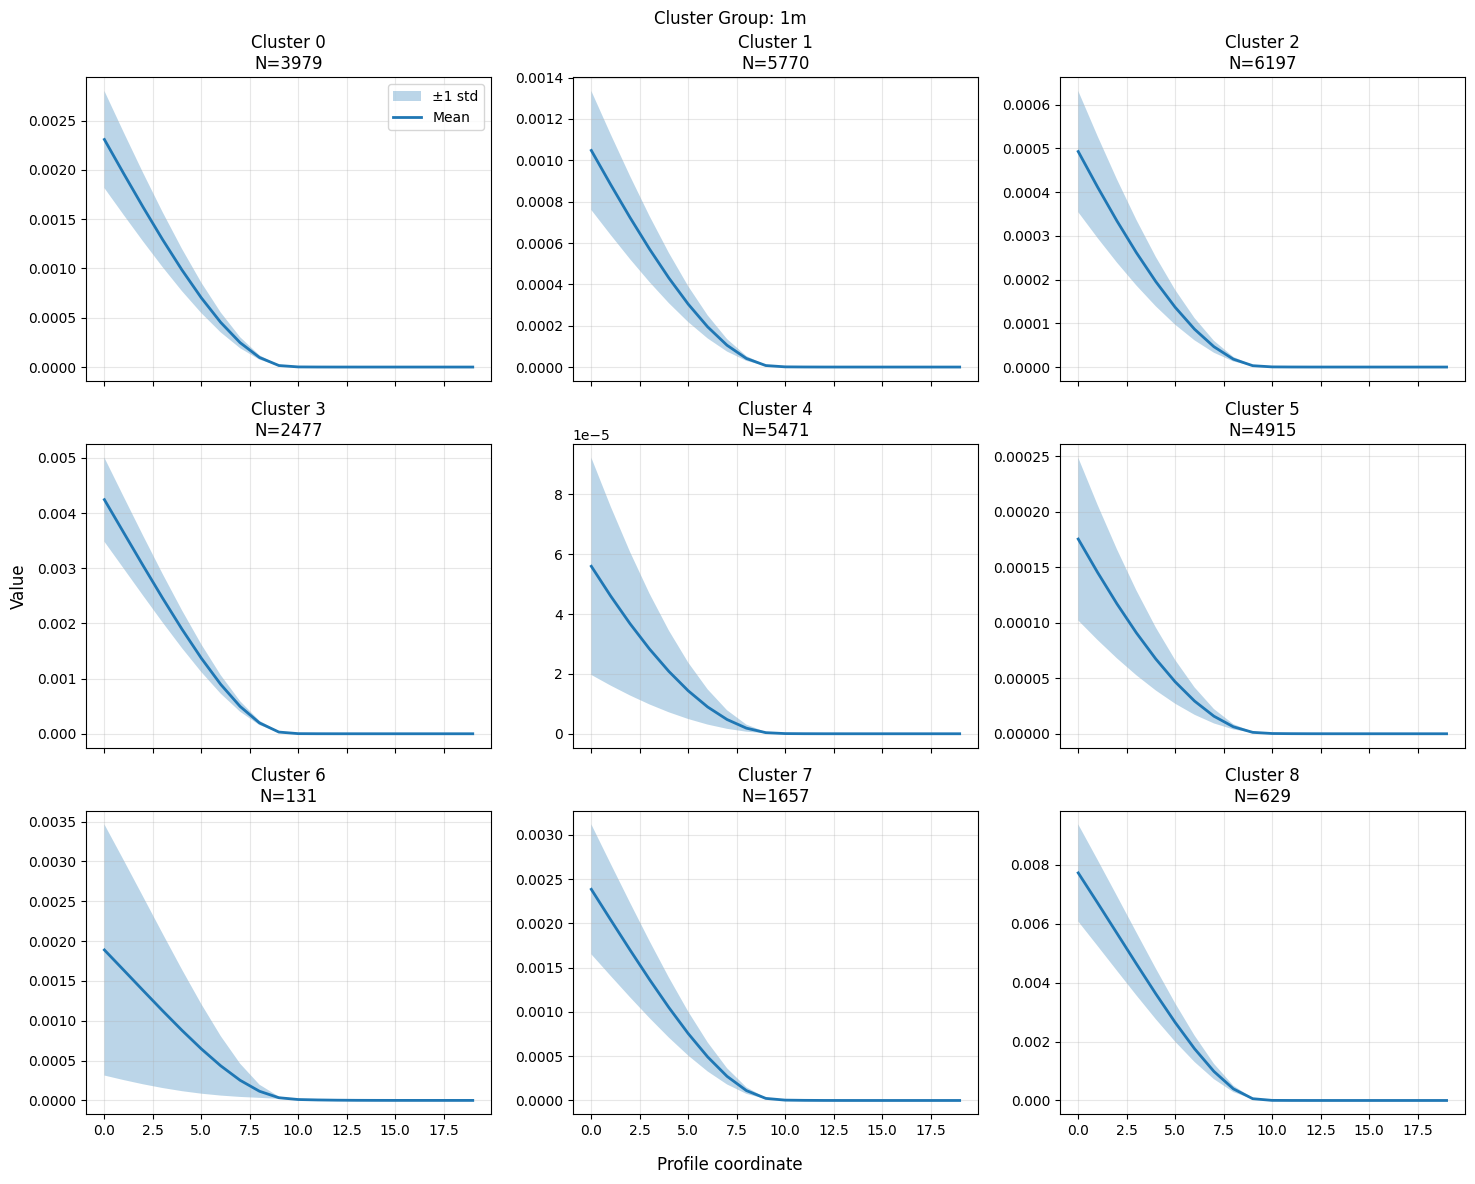

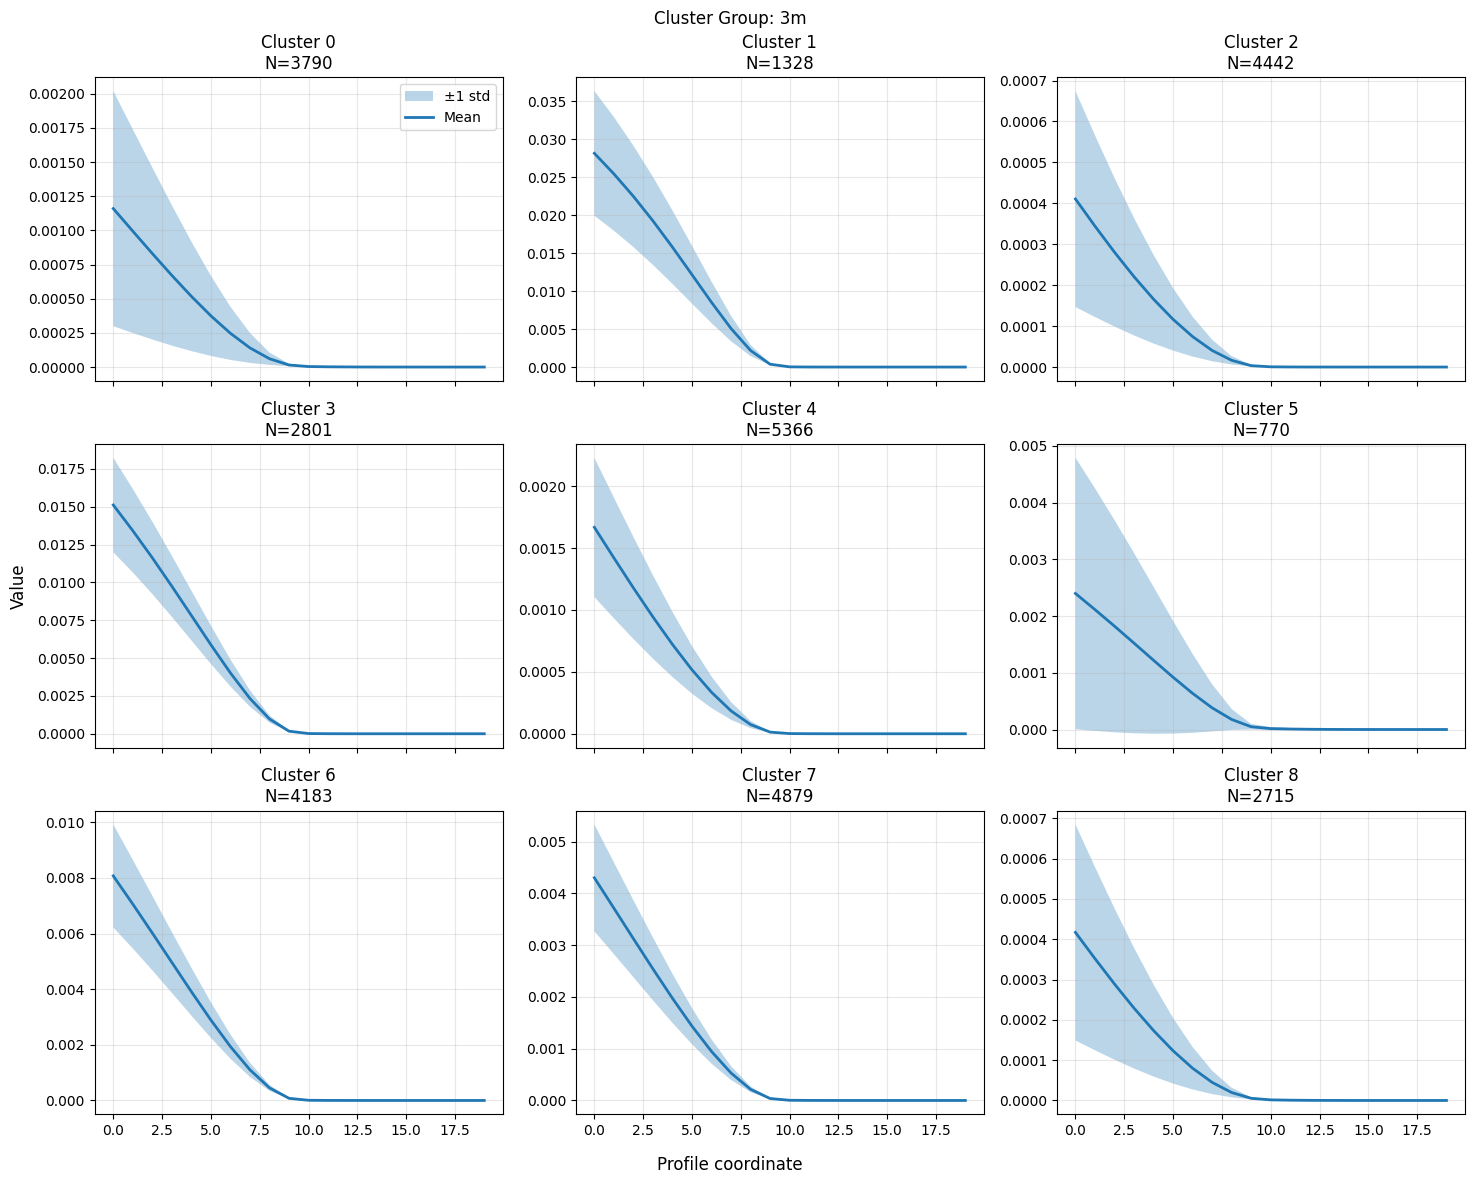

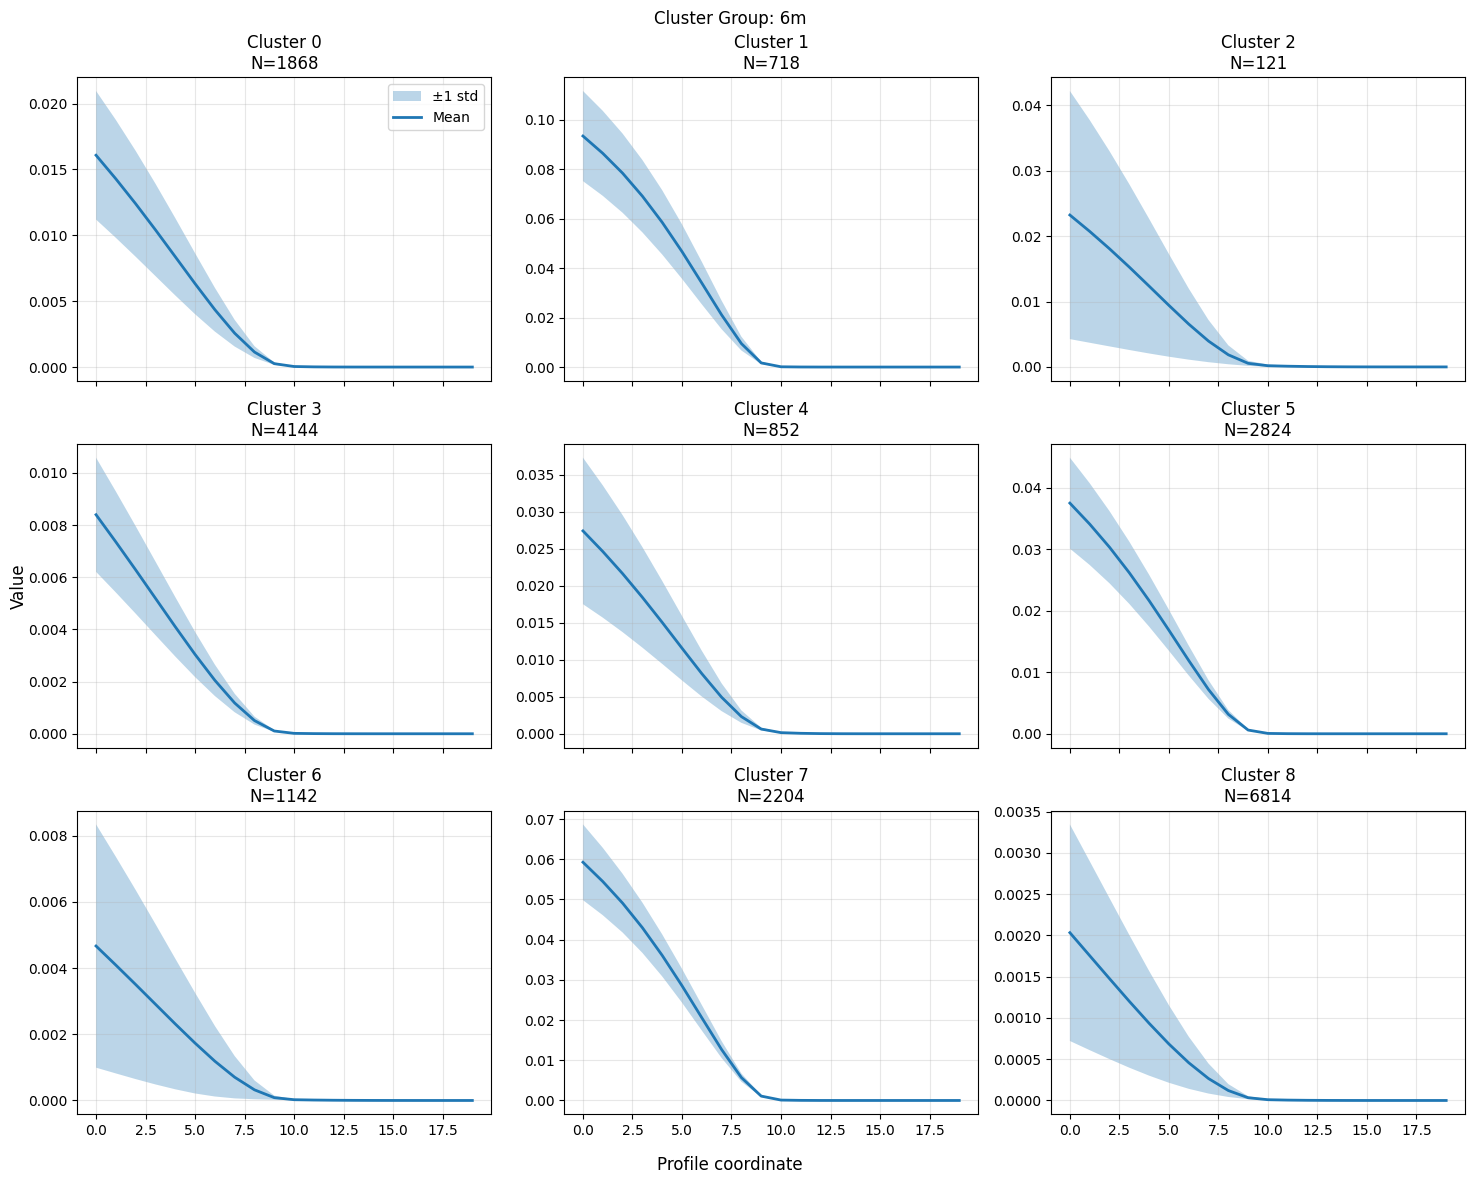

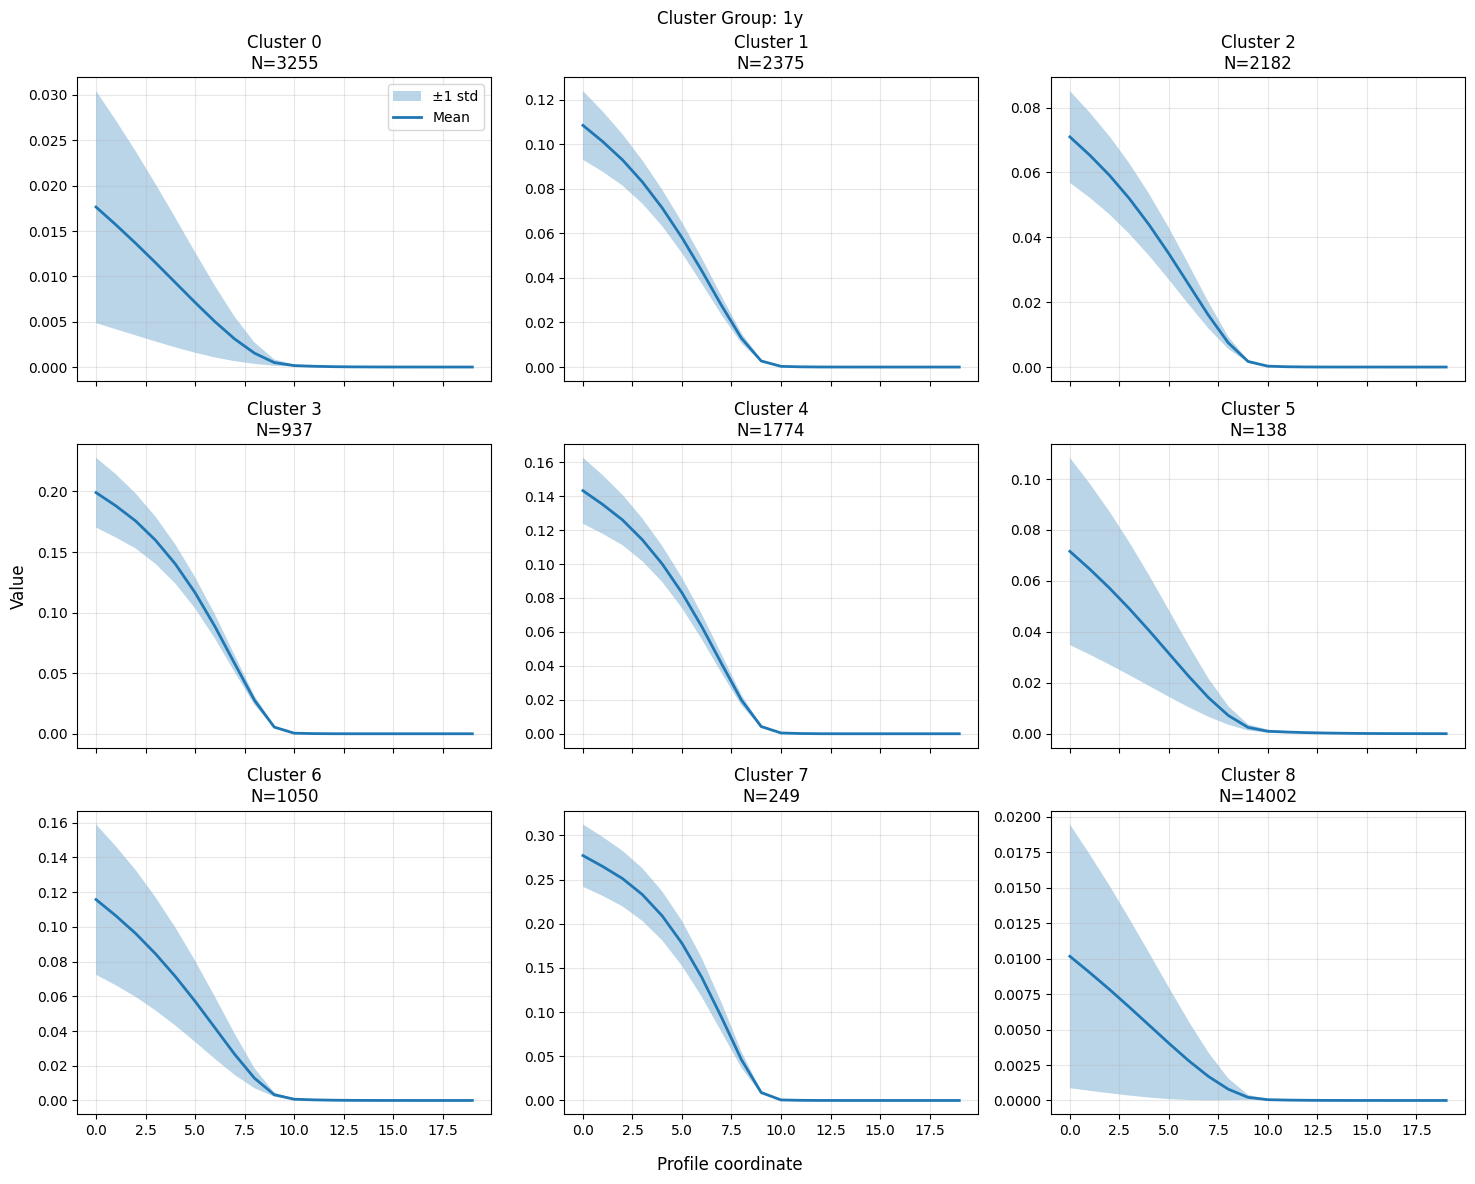

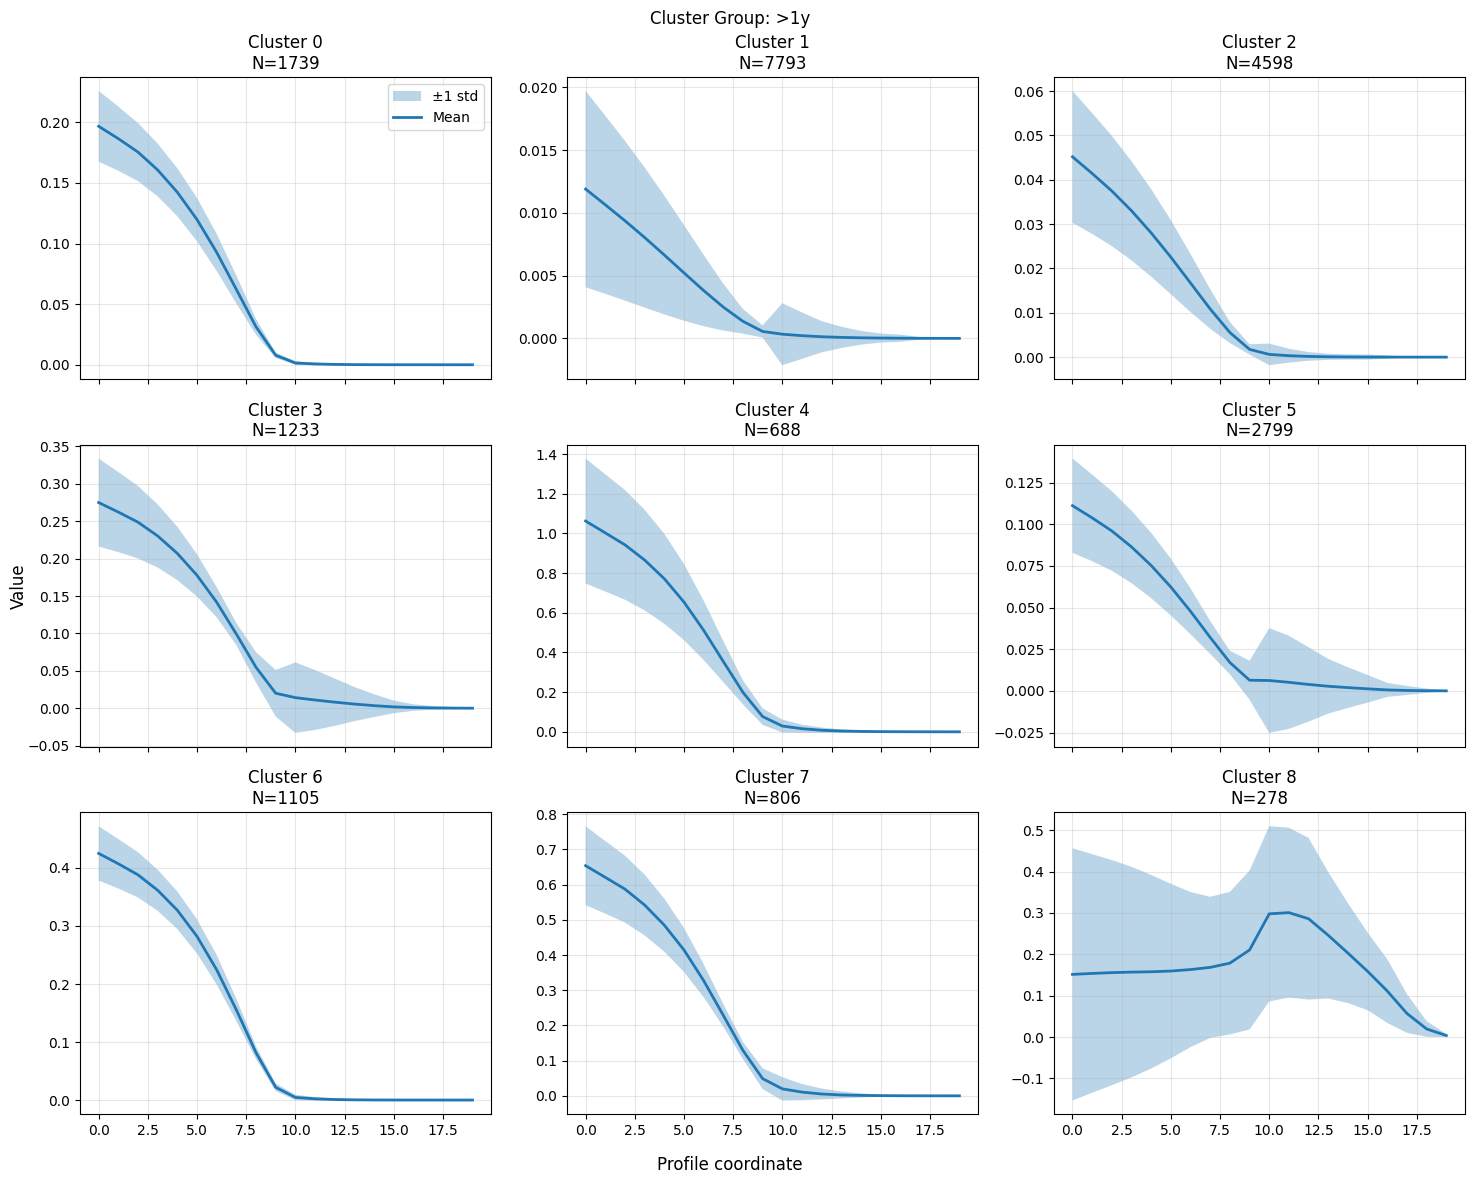

In [40]:
for i, (mLabel, result) in enumerate(R.items()):
    labels = result["labels"]
    data = result["data"]
    plot_cluster_profiles(data, labels, mLabel, f"Cluster_group_{i}.png")
    